In [1]:
import pandas  as  pd 
import  numpy  as  np  
import matplotlib.pyplot  as  plt 
import   seaborn  as  sns 
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_row=pd.read_csv("FoodFacts.products.170k_May26.csv")
df_row.head()

,_id,product_name_en,ecoscore_grade,ingredients_text_en,categories,categories_hierarchy[0],categories_hierarchy[1],categories_hierarchy[2],categories_hierarchy[3],categories_hierarchy[4],...,packaging_hierarchy[43],packaging_hierarchy[44],packaging_hierarchy[45],packaging_hierarchy[46],packaging_hierarchy[47],packaging_hierarchy[48],packaging_hierarchy[49],packaging_hierarchy[50],packaging_hierarchy[51],packaging_hierarchy[52]
0,7896010000000.0,123,f,NaN,"Beverages and beverages preparations, Beverage...",en:beverages-and-beverages-preparations,en:plant-based-foods-and-beverages,en:beverages,en:plant-based-foods,en:beverage-preparations,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8410390000000.0,2022,e,NaN,"Dranken en drankbereidingen,Dranken,Alcoholisc...",en:beverages-and-beverages-preparations,en:beverages,en:alcoholic-beverages,en:wines,en:red-wines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8901060000000.0,5050,c,NaN,Biscuits,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4004200000000.0,5.00017E+12,c,NaN,Green tapenades,en:spreads,en:salted-spreads,en:tapenades,en:green-tapenades,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5203060000000.0,5.20306E+12,d,dog,Chocolate Cookie,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits-and-crackers,en:biscuits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_row.shape

(171490, 509)

In [4]:
df_row["ecoscore_grade"].value_counts()

ecoscore_grade
d         49480
b         34570
c         25989
e         24354
a         23288
f         10102
a-plus     3707
Name: count, dtype: int64

In [5]:
df_row.columns

Index(['_id', 'product_name_en', 'ecoscore_grade', 'ingredients_text_en',
       'categories', 'categories_hierarchy[0]', 'categories_hierarchy[1]',
       'categories_hierarchy[2]', 'categories_hierarchy[3]',
       'categories_hierarchy[4]',
       ...
       'packaging_hierarchy[43]', 'packaging_hierarchy[44]',
       'packaging_hierarchy[45]', 'packaging_hierarchy[46]',
       'packaging_hierarchy[47]', 'packaging_hierarchy[48]',
       'packaging_hierarchy[49]', 'packaging_hierarchy[50]',
       'packaging_hierarchy[51]', 'packaging_hierarchy[52]'],
      dtype='object', length=509)

In [6]:
df_row[["categories","ecoscore_grade"]].sample(40)

,categories,ecoscore_grade
113071,"Plant-based foods and beverages, Plant-based f...",d
33114,"Meats and their products, Meat preparations, T...",e
158622,"Desserts, Frozen foods, Frozen desserts, Ice c...",b
143300,"Aliments et boissons à base de végétaux, Alime...",b
27067,"Plant-based foods and beverages, Plant-based f...",c
119175,"Dairies, Fermented foods, Fermented milk produ...",c
111215,"Dairies, Milks",d
53026,"Condiments,Sauces,Sauces tomate,Ketchup",b
74814,en:barbecue-sauces,b
20205,"Snacks, Sweet snacks, Biscuits and cakes, Past...",c


In [7]:
df_row.loc[55101,"categories"]

'Dairies, Fermented foods, Fermented milk products, Spreads, Cheeses, Salted spreads, Cheese spreads'

In [8]:
df_row.isnull().sum()

_id                             0
product_name_en             58008
ecoscore_grade                  0
ingredients_text_en         97165
categories                      5
                            ...  
packaging_hierarchy[48]    171489
packaging_hierarchy[49]    171489
packaging_hierarchy[50]    171489
packaging_hierarchy[51]    171489
packaging_hierarchy[52]    171489
Length: 509, dtype: int64

In [9]:
df_row.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171490 entries, 0 to 171489
Columns: 509 entries, _id to packaging_hierarchy[52]
dtypes: float64(2), object(507)
memory usage: 666.0+ MB


In [10]:
df_clean = df_row[['ingredients_text_en', 'ecoscore_grade', 'categories']]

In [11]:
df_clean['main_category'] = df_clean['categories'].str.split(',').str[0]
df_clean = df_clean.drop(columns=['categories'])

In [12]:
df_clean.sample(20)

,ingredients_text_en,ecoscore_grade,main_category
132319,NaN,a-plus,Boissons
21415,NaN,c,Snacks
135550,NaN,b,Condiments
170249,NaN,a,bananen
73532,ORGANICALLY GROWN ROOIBOS (REDBUSH) BLENDED AN...,a,Tea bags
111988,NaN,b,Jams
139367,NaN,c,Milchprodukte
140819,NaN,b,en:spring-rolls
135042,NaN,f,Aliments et boissons à base de végétaux
53368,"tomato paste, water, apple cider vinegar, date...",b,Condiments


In [13]:
df_clean.isnull().sum()

ingredients_text_en    97165
ecoscore_grade             0
main_category              5
dtype: int64

In [14]:
df_clean = df_clean.dropna(subset=['ingredients_text_en', 'main_category'])


In [15]:
df_clean.isnull().sum()

ingredients_text_en    0
ecoscore_grade         0
main_category          0
dtype: int64

<Axes: xlabel='ecoscore_grade', ylabel='count'>

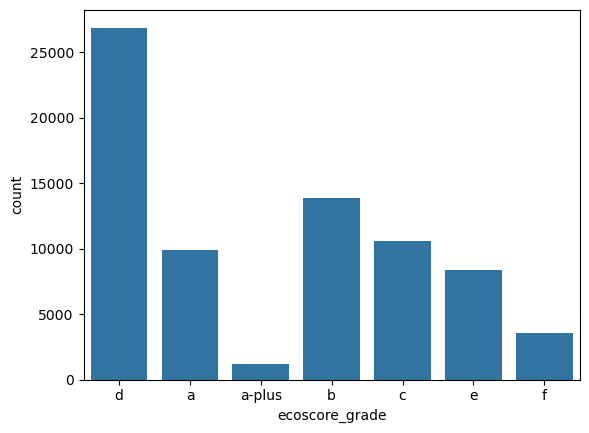

In [16]:
sns.countplot(x="ecoscore_grade", data=df_clean)

In [17]:
df_clean.sample(20)

,ingredients_text_en,ecoscore_grade,main_category
100326,"PASTEURIZED CREAM (MILK), SALT.",d,Dairies
85806,"Red Leicester cheese (Leicester cheese (milk),...",c,Dairies
26030,"Cranberries (sugar, sunflower oil), walnuts, b...",c,Snacks
102131,"Toasted crisp rice coated With milk chocolate,...",e,en:chocolate-cereals
112667,Premium brewed green and black tea using filte...,d,Beverages
398,100% Organic Honey,a,Breakfasts
63407,"Milk chocolate (sugar, whole milk, cocoa butte...",c,Snacks
37203,"Ground yellow corn, vegetable oil (contains on...",b,Snacks
108048,"Water, Rapeseed Oil (27%), Vinegar, Sugar, Cor...",c,Condiments
40712,"Cookies: enriched wheat flour (wheat flour, ni...",c,Snacks


In [18]:
df_clean.shape

(74325, 3)

In [19]:
df_clean["ingredients_text_en"].duplicated().sum()


np.int64(14827)

In [20]:
df_clean.duplicated(
    subset=['ingredients_text_en', 'ecoscore_grade']
).sum()

np.int64(13957)

In [21]:
conflicts = (
    df_clean.groupby('ingredients_text_en')['ecoscore_grade']
    .nunique())

conflicts = conflicts[conflicts > 1]

len(conflicts)

769

In [22]:
df_clean = df_clean.drop_duplicates(
    subset=['ingredients_text_en', 'ecoscore_grade']
)

In [23]:
df_clean.shape

(60368, 3)

In [24]:
conflicts = (
    df_clean.groupby('ingredients_text_en')['ecoscore_grade']
    .nunique())

conflicts = conflicts[conflicts > 1]

len(conflicts)

769

In [25]:
hierarchy_cols = [
    col for col in df_row.columns
    if "ingredients_hierarchy" in col
]
df_clean["ingredient_hierarchy_text"] = (
    df_row[hierarchy_cols]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

In [26]:
import re
import unicodedata

def clean_ingredients(text):

    if pd.isnull(text):
        return ""

    text = text.lower()

    text = unicodedata.normalize('NFKD', text)

    # remove urls
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove phone/device garbage
    text = re.sub(r'galaxy\s\w+.*', ' ', text)

    # remove percentages
    text = re.sub(r'\d+%', ' ', text)

    # remove units like 100g, 0mg, 250ml
    text = re.sub(r'\b\d+(g|mg|ml|kg|cl|oz|lb)\b', ' ', text)

    # remove standalone pure numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # remove punctuation
    text = re.sub(r'[\(\)\[\]\{\},;:/\\\-\"]', ' ', text)

    # KEEP letters + additive codes like e330
    text = re.sub(r'[^a-zA-ZÀ-ÿ0-9\s]', ' ', text)

    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [27]:
df_clean['ingredients_text_en'] = (
    df_clean['ingredients_text_en']
    .apply(clean_ingredients))

In [28]:
df_clean["main_category"]= (df_clean["main_category"].apply(clean_ingredients))

In [29]:
df_clean["ingredient_hierarchy_text"]= (df_clean["ingredient_hierarchy_text"].apply(clean_ingredients))

In [30]:
df_clean = df_clean[
    (df_clean['ingredients_text_en'].str.strip() != '') &
    (df_clean['main_category'].str.strip() != '') &(df_clean['ingredient_hierarchy_text'].str.strip() != '')
]


In [31]:
df_clean.isnull().sum()

ingredients_text_en          0
ecoscore_grade               0
main_category                0
ingredient_hierarchy_text    0
dtype: int64

In [32]:
df_clean.sample(10)

,ingredients_text_en,ecoscore_grade,main_category,ingredient_hierarchy_text
84314,raisins sunflower oil,b,plant based foods and beverages,en raisin en fruit en berries en grape en sunf...
85978,red wine vinegar water potassium metabisulfite...,b,condiments,en red wine vinegar en vinegar en water en e22...
870,organic black eyed peas water sea salt,b,plant based foods and beverages,en black eyed pea en vegetable en legume en pu...
105149,corn sunflower and or canola oil sugar salt na...,b,corn chips,en corn en cereal en sunflower en plant en can...
100498,organic white corn organic vegetable oil organ...,b,snacks,en white corn en cereal en corn en vegetable o...
9379,berry cherry nuts,a,plant based foods and beverages,en cherry en fruit en prunus species fruit en nut
52180,water sugar mesona mesona chinensis frangipani...,a,beverages and beverages preparations,en water en sugar en added sugar en disacchari...
42623,rolled oats organic corn meal bittersweet chip...,c,snacks,en oat flakes en cereal en oat en cornmeal en ...
54856,cheddar cheese pasteurized milk cheese culture...,d,dairies,en cheddar en dairy en cheese en swiss cheese ...
107159,water almonds calcium phosphates sea salt stab...,b,plant based foods and beverages,en water en almond en nut en tree nut en e341 ...


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,stop_words="english"
)


In [34]:
ordinal_mapping = {
    "a-plus": 0,
    "a": 1,
    "b": 2,
    "c": 3,
    "d": 4,
    "e": 5,
    "f": 6
}

In [35]:
df_clean["ecoscore_grade"] = df_clean["ecoscore_grade"].map(ordinal_mapping)

In [36]:
y=df_clean["ecoscore_grade"]

In [37]:
df_clean.isnull().sum()

ingredients_text_en          0
ecoscore_grade               0
main_category                0
ingredient_hierarchy_text    0
dtype: int64

In [38]:
X=df_clean.drop(columns=["ecoscore_grade"])

In [39]:
X

,ingredients_text_en,main_category,ingredient_hierarchy_text
4,dog,chocolate cookie,en dog
6,green asparagus water salt acidity regulator s...,plant based foods and beverages,en green asparagus en vegetable en shoot veget...
7,single cream pasteurised egg yolk sugar milk p...,dairies,en single cream en dairy en cream en pasteuris...
8,peach white sugar brown sugar concentrated lem...,plant based foods and beverages,en peach en fruit en prunus species fruit en w...
10,honey,breakfasts,en honey en added sugar
...,...,...,...
171352,es snack de patata con sabor a nata agriaya ce...,potato crisps,en es snack de patata con sabor a nata agriaya...
171363,in shell peanuts,alimente s i ba uturi pe baza de plante,ro arahide i n coaja
171425,organic dulse flakes,seaweeds and their products,en dulse en algae
171467,green tea,green teas,en green tea en plant en tea


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

preprocess = ColumnTransformer(
    transformers=[
        ('tfidf_ing', tfidf, 'ingredients_text_en'),
        ('tfidf_cat', tfidf, 'main_category'),
        ('tfidf_hier', tfidf, 'ingredient_hierarchy_text')
    ],
    remainder='drop'   # or 'passthrough' if you want to keep numeric columns
)

X_text = preprocess.fit_transform(df_clean)


In [41]:
X_text.shape

(59711, 21850)

In [43]:
y.shape

(59711,)

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [45]:
print("X_train shape", X_train.shape)
print("X_test shape", X_test.shape)
print("y_train shape", y_train.shape)
print("y_test  shape", y_test.shape)


X_train shape (47768, 21850)
X_test shape (11943, 21850)
y_train shape (47768,)
y_test  shape (11943,)


In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [47]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.18      0.43      0.25       216
           1       0.64      0.62      0.63      1496
           2       0.72      0.68      0.70      2312
           3       0.60      0.62      0.61      1872
           4       0.86      0.73      0.79      4114
           5       0.59      0.70      0.64      1391
           6       0.56      0.74      0.64       542

    accuracy                           0.68     11943
   macro avg       0.59      0.65      0.61     11943
weighted avg       0.71      0.68      0.69     11943



In [49]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=0.1,
    class_weight='balanced'
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.17      0.26      0.21       216
           1       0.66      0.68      0.67      1496
           2       0.72      0.72      0.72      2312
           3       0.66      0.58      0.62      1872
           4       0.83      0.78      0.81      4114
           5       0.60      0.69      0.64      1391
           6       0.60      0.71      0.65       542

    accuracy                           0.70     11943
   macro avg       0.61      0.63      0.62     11943
weighted avg       0.71      0.70      0.71     11943



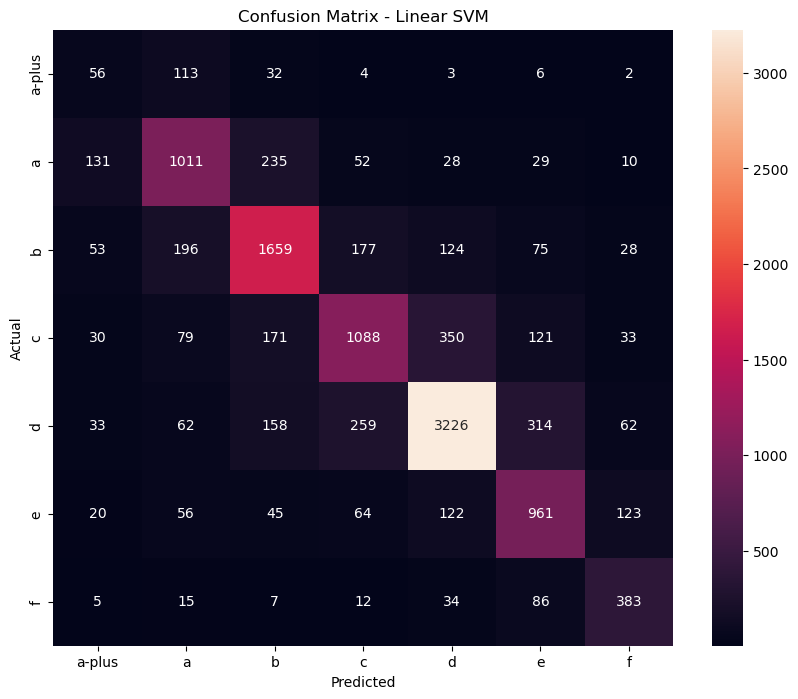

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ['a-plus', 'a', 'b', 'c', 'd', 'e', 'f']

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [52]:
import pandas as pd

feature_names = preprocess.get_feature_names_out()

row_df = pd.DataFrame(
    X_train[0].toarray(),
    columns=feature_names
)

row_df.T.sort_values(
    by=0,
    ascending=False
).head(20)

,0
tfidf_cat__snacks,1.000000
tfidf_hier__blueberry en,0.192570
tfidf_hier__blueberry,0.189761
tfidf_ing__glucose syrup,0.176937
tfidf_ing__concentrate carrot,0.175419
tfidf_ing__butter corn,0.173710
tfidf_ing__agent e500,0.173710
tfidf_ing__e420,0.173710
tfidf_ing__dietary fibre,0.171141
tfidf_ing__e440,0.169293


In [65]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=300,
    random_state=42
)

X_svd = svd.fit_transform(X_text)

In [68]:
from sklearn.model_selection import train_test_split

X_train_svd, X_test_svd, y_train, y_test = train_test_split(
    X_svd,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [54]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [55]:
y_pred_rf = rf_model.predict(X_test)

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))



              precision    recall  f1-score   support

           0       0.08      0.47      0.14       216
           1       0.59      0.51      0.55      1496
           2       0.65      0.68      0.66      2312
           3       0.67      0.53      0.59      1872
           4       0.85      0.73      0.79      4114
           5       0.60      0.62      0.61      1391
           6       0.62      0.60      0.61       542

    accuracy                           0.64     11943
   macro avg       0.58      0.59      0.56     11943
weighted avg       0.70      0.64      0.66     11943



In [57]:
df_row["ecoscore_grade"].value_counts()

ecoscore_grade
d         49480
b         34570
c         25989
e         24354
a         23288
f         10102
a-plus     3707
Name: count, dtype: int64

In [58]:
df_clean.shape

(59711, 4)

In [94]:
X_test.toarray()[:5]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='accuracy')

In [63]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.6912995978803057


In [57]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=7,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

In [58]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.45      0.06      0.11       216
           1       0.69      0.71      0.70      1496
           2       0.71      0.78      0.74      2312
           3       0.74      0.59      0.66      1872
           4       0.78      0.86      0.82      4114
           5       0.67      0.66      0.66      1391
           6       0.75      0.62      0.68       542

    accuracy                           0.73     11943
   macro avg       0.68      0.61      0.62     11943
weighted avg       0.73      0.73      0.73     11943



In [62]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(7.8799076212471135), np.int64(1): np.float64(1.1399933177413966), np.int64(2): np.float64(0.7380488860047588), np.int64(3): np.float64(0.9116900467601871), np.int64(4): np.float64(0.4147571871391236), np.int64(5): np.float64(1.2266762538198814), np.int64(6): np.float64(3.1461502996772706)}


In [63]:
sample_weights = y_train.map(class_weights)

In [69]:
xgb_model.fit(
    X_train_svd,
    y_train,
    sample_weight=sample_weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=7, ...)

In [70]:
import pandas as pd

y_train = pd.Series(y_train)

In [71]:
y_pred_xgb = xgb_model.predict(X_test_svd)

In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.23      0.21      0.22       216
           1       0.65      0.68      0.67      1496
           2       0.69      0.73      0.71      2312
           3       0.64      0.63      0.64      1872
           4       0.85      0.77      0.81      4114
           5       0.59      0.69      0.64      1391
           6       0.63      0.62      0.62       542

    accuracy                           0.70     11943
   macro avg       0.61      0.62      0.62     11943
weighted avg       0.71      0.70      0.71     11943

